# Complex I Sequence Extraction

Extract ND gene sequences from:
- `amtdb_seqs/` - Ancient mtDNA Database (2,022 ancient samples)

Uses GFF3 annotations for gene coordinates

In [1]:
import numpy as np
from pathlib import Path
from Bio import SeqIO
from Bio.Seq import Seq

# Load rCRS reference sequence
RCRS_PATH = Path("data/rCRS.fa")
rcrs_record = next(SeqIO.parse(RCRS_PATH, "fasta"))
RCRS_SEQ = str(rcrs_record.seq)
print(f"Loaded rCRS reference: {rcrs_record.id}, length={len(RCRS_SEQ)}")

Loaded rCRS reference: NC_012920.1, length=16569


In [ ]:
# Parse GFF3 for Complex I (ND) gene coordinates and extract reference subsequences
def parse_gff3_nd_genes(gff_path, ref_seq):
    """Extract ND gene CDS coordinates from GFF3 and slice reference sequence.
    
    Returns:
        nd_genes: dict of gene metadata (coordinates, strand, lengths, ids)
        nd_ref_seqs: dict of reference subsequences for each gene (coding strand orientation)
    """
    nd_genes = {}
    nd_ref_seqs = {}
    
    with open(gff_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.strip().split("\t")
            if len(parts) < 9:
                continue
            feature_type = parts[2]
            if feature_type != "CDS":
                continue
            
            seq_id = parts[0]
            source = parts[1]
            
            # Parse attributes
            attrs = dict(item.split("=") for item in parts[8].split(";") if "=" in item)
            gene = attrs.get("gene", "")
            # Only ND genes (Complex I)
            if not gene.startswith("ND"):
                continue
            
            start = int(parts[3])
            end = int(parts[4])
            strand = parts[6]
            phase = parts[7]
            
            # Extract additional identifiers
            protein_id = attrs.get("protein_id", "")
            product = attrs.get("product", "")
            
            # Extract reference subsequence (GFF is 1-based inclusive, Python is 0-based exclusive)
            ref_subseq = ref_seq[start - 1 : end].upper()
            # Reverse complement for minus strand genes (ND6) to get coding strand
            if strand == "-":
                ref_subseq = str(Seq(ref_subseq).reverse_complement())
            
            nd_genes[gene] = {
                "seq_id": seq_id,
                "source": source,
                "start": start,
                "end": end,
                "strand": strand,
                "phase": phase,
                "length_nt": end - start + 1,
                "length_aa": (end - start + 1) // 3,
                "protein_id": protein_id,
                "product": product,
            }
            nd_ref_seqs[gene] = ref_subseq
    
    return nd_genes, nd_ref_seqs

GFF_PATH = Path("data/NC_012920.1.gff3")
nd_genes, nd_ref_seqs = parse_gff3_nd_genes(GFF_PATH, RCRS_SEQ)

print(f"Complex I (ND) genes from GFF3:\n")
print(f"{'Gene':<6} {'Seq ID':<14} {'Start':>6} {'End':>6} {'Strand':>6} {'NT len':>7} {'Protein ID':<16} {'Product'}")
print("-" * 110)
for gene, info in sorted(nd_genes.items(), key=lambda x: x[1]["start"]):
    print(f"{gene:<6} {info['seq_id']:<14} {info['start']:>6} {info['end']:>6} {info['strand']:>6} {info['length_nt']:>7} {info['protein_id']:<16} {info['product']}")

Complex I (ND) genes from GFF3:

Gene   Seq ID          Start    End Strand  NT len Protein ID       Product
--------------------------------------------------------------------------------------------------------------
ND1    NC_012920.1      3307   4262      +     956 YP_003024026.1   NADH dehydrogenase subunit 1
ND2    NC_012920.1      4470   5511      +    1042 YP_003024027.1   NADH dehydrogenase subunit 2
ND3    NC_012920.1     10059  10404      +     346 YP_003024033.1   NADH dehydrogenase subunit 3
ND4L   NC_012920.1     10470  10766      +     297 YP_003024034.1   NADH dehydrogenase subunit 4L
ND4    NC_012920.1     10760  12137      +    1378 YP_003024035.1   NADH dehydrogenase subunit 4
ND5    NC_012920.1     12337  14148      +    1812 YP_003024036.1   NADH dehydrogenase subunit 5
ND6    NC_012920.1     14149  14673      -     525 YP_003024037.1   NADH dehydrogenase subunit 6


In [ ]:
# Load ancient mtDNA sequences
AMTDB_DIR = Path("data/amtdb_seqs")
REF_LEN = 16569

def load_mtdna_sequences(seq_dir):
    """Load all mtDNA sequences from directory of FASTA files."""
    sequences = {}
    for fa_path in sorted(seq_dir.glob("*.fa")):
        sample_id = fa_path.stem
        record = next(SeqIO.parse(fa_path, "fasta"))
        sequences[sample_id] = str(record.seq)
    return sequences

amtdb_sequences = load_mtdna_sequences(AMTDB_DIR)
print(f"Loaded {len(amtdb_sequences)} ancient mtDNA sequences")

# Check length distribution
lengths = [len(seq) for seq in amtdb_sequences.values()]
same_as_ref = sum(1 for l in lengths if l == REF_LEN)
print(f"\nLength: min={min(lengths)}, max={max(lengths)}, ref={REF_LEN}")
print(f"Match reference: {same_as_ref} / {len(lengths)}")

# Split by length
amtdb_ref_length = {sid: seq for sid, seq in amtdb_sequences.items() if len(seq) == REF_LEN}
amtdb_variable = {sid: seq for sid, seq in amtdb_sequences.items() if len(seq) != REF_LEN}

print(f"\nCoordinate extraction: {len(amtdb_ref_length)} sequences")
print(f"Need BLAST alignment:  {len(amtdb_variable)} sequences")

Loaded 2022 ancient mtDNA sequences

Length: min=16424, max=16583, ref=16569
Match reference: 1374 / 2022

Coordinate extraction: 1374 sequences
Need BLAST alignment:  648 sequences


In [ ]:
# Import Smith-Waterman alignment for variable-length sequences
from alignment import smith_waterman, extract_gene, extract_nd_genes_sw

# Test on a single example
test_sample = next(iter(amtdb_variable.keys()))
test_seq = amtdb_variable[test_sample]
print(f"Testing Smith-Waterman (affine gaps) on sample: {test_sample}")
print(f"Sample length: {len(test_seq)} (ref: {REF_LEN}, diff: {len(test_seq) - REF_LEN})")

# Test extraction with windowed search
print(f"\n{'Gene':<6} {'Score':>7} {'Coverage':>10} {'Region':<18} {'Gaps (Q/R)':>12}")
print("-" * 60)

for gene in sorted(nd_genes.keys(), key=lambda x: nd_genes[x]["start"]):
    ref_seq = nd_ref_seqs[gene]
    expected_start = nd_genes[gene]['start'] - 1
    
    result = extract_gene(test_seq, ref_seq, expected_start=expected_start)
    
    region = f"{result['start']}-{result['end']}"
    gaps = f"{result['gaps_in_query']}/{result['gaps_in_ref']}"
    status = "OK" if result['sequence'] else "FAIL"
    
    print(f"{gene:<6} {result['score']:>7.0f} {result['coverage']:>9.1%} {region:<18} {gaps:>12}  {status}")

In [ ]:
# Extract ND genes from variable-length samples using Smith-Waterman
amtdb_nd_seqs_sw, sw_stats = extract_nd_genes_sw(
    amtdb_variable, 
    nd_genes, 
    nd_ref_seqs,
    window=500,
    min_coverage=0.9
)

# Merge with coordinate-extracted sequences
print(f"\n{'='*60}")
print("MERGED RESULTS: Coordinate extraction + Smith-Waterman")
print(f"{'='*60}")
print(f"\n{'Gene':<6} {'Coord':>8} {'S-W':>8} {'S-W fail':>10} {'Total':>8}")
print("-" * 45)

for gene in sorted(nd_genes.keys(), key=lambda x: nd_genes[x]["start"]):
    n_coord = len(amtdb_nd_seqs[gene])
    n_sw = len(amtdb_nd_seqs_sw[gene])
    n_sw_fail = len(amtdb_variable) - n_sw
    
    # Merge into main dict
    amtdb_nd_seqs[gene].update(amtdb_nd_seqs_sw[gene])
    n_total = len(amtdb_nd_seqs[gene])
    
    print(f"{gene:<6} {n_coord:>8} {n_sw:>8} {n_sw_fail:>10} {n_total:>8}")

print(f"\nTotal samples with all genes: {len(amtdb_sequences)}")
print(f"Successfully extracted: {len(amtdb_nd_seqs['ND1'])} samples")

In [ ]:
# Extract Complex I (ND) gene sequences from ref-length ancient mtDNA samples
import re

def normalize_sequence(seq):
    """Map non-standard nucleotides to N.
    
    Keeps: A, C, G, T, N
    Maps to N: -, Y, R, M, W, K, S, and any other non-ACGTN characters
    """
    return re.sub(r'[^ACGTN]', 'N', seq.upper())

def extract_nd_genes(sequences, nd_genes):
    """Extract ND gene subsequences from full mtDNA sequences.
    
    Extracts coding strand orientation (reverse complement for minus strand genes).
    Normalizes non-standard nucleotides (IUPAC ambiguity codes, gaps) to N.
    
    Args:
        sequences: dict of {sample_id: full_mtdna_sequence}
        nd_genes: dict of gene metadata with start/end coordinates
    
    Returns:
        dict of {gene: {sample_id: gene_sequence}}
    """
    amtdb_nd_seqs = {gene: {} for gene in nd_genes}
    for sample_id, full_seq in sequences.items():
        for gene, info in nd_genes.items():
            # GFF3 1-based inclusive -> Python 0-based exclusive
            start = info["start"] - 1
            end = info["end"]
            subseq = full_seq[start:end].upper()
            # Reverse complement for minus strand genes (ND6) to get coding strand
            if info["strand"] == "-":
                subseq = str(Seq(subseq).reverse_complement())
            # Normalize non-standard characters to N
            subseq = normalize_sequence(subseq)
            amtdb_nd_seqs[gene][sample_id] = subseq
    return amtdb_nd_seqs

amtdb_nd_seqs = extract_nd_genes(amtdb_ref_length, nd_genes)

# Verify normalization - count characters across all extracted sequences
from collections import Counter
all_chars = Counter()
for gene_seqs in amtdb_nd_seqs.values():
    for seq in gene_seqs.values():
        all_chars.update(seq)

print(f"Extracted ND genes from {len(amtdb_ref_length)} samples:\n")
print(f"{'Gene':<6} {'Samples':>8} {'Length':>8}")
print("-" * 26)
for gene in sorted(nd_genes.keys(), key=lambda x: nd_genes[x]["start"]):
    seqs = amtdb_nd_seqs[gene]
    seq_len = len(next(iter(seqs.values())))
    print(f"{gene:<6} {len(seqs):>8} {seq_len:>8}")

print(f"\nCharacter composition after normalization:")
total = sum(all_chars.values())
for char in sorted(all_chars.keys()):
    count = all_chars[char]
    print(f"  {char}: {count:>10,} ({100*count/total:.3f}%)")

Extracted ND genes from 1374 samples:

Gene    Samples   Length
--------------------------
ND1        1374      956
ND2        1374     1042
ND3        1374      346
ND4L       1374      297
ND4        1374     1378
ND5        1374     1812
ND6        1374      525

Character composition after normalization:
  A:  2,473,965 (28.328%)
  C:  2,696,037 (30.871%)
  G:  1,072,809 (12.284%)
  N:    244,235 (2.797%)
  T:  2,246,098 (25.719%)


In [5]:
# Load precomputed contact summary
contact_data = np.load("data/mito_contact_summary.npz", allow_pickle=True)

# Gene name mapping (structure uses MT- prefix, GFF uses bare names)
GENE_NAME_MAP = {"MT-ND1": "ND1", "MT-ND2": "ND2", "MT-ND3": "ND3",
                 "MT-ND4": "ND4", "MT-ND4L": "ND4L", "MT-ND5": "ND5", "MT-ND6": "ND6"}

# Build mito_contact_summary dict
mito_contact_summary = {}
for mt_gene, gff_gene in GENE_NAME_MAP.items():
    mito_contact_summary[gff_gene] = {
        "residues": contact_data[f"{mt_gene}_residues"],
        "struct_len": len(contact_data[f"{mt_gene}_residues"]),
        "contacts_per_res": contact_data[f"{mt_gene}_contacts_per_res"],
        "downweight": contact_data[f"{mt_gene}_downweight"],
        "intra_per_res": contact_data[f"{mt_gene}_intra_per_res"],
        "inter_mt_per_res": contact_data[f"{mt_gene}_inter_mt_per_res"],
        "inter_nuc_per_res": contact_data[f"{mt_gene}_inter_nuc_per_res"],
    }

print("Loaded contact summary:\n")
print(f"{'Gene':<6} {'Struct':>8} {'Genomic':>8} {'Mean DW':>10}")
print("-" * 36)
for gene in sorted(mito_contact_summary.keys(), key=lambda x: nd_genes[x]["start"]):
    data = mito_contact_summary[gene]
    genomic = nd_genes[gene]["length_aa"]
    mean_dw = data["downweight"].mean()
    print(f"{gene:<6} {data['struct_len']:>8} {genomic:>8} {mean_dw:>10.4f}")

Loaded contact summary:

Gene     Struct  Genomic    Mean DW
------------------------------------
ND1         316      318     0.1755
ND2         347      347     0.1828
ND3         115      115     0.1962
ND4L         98       99     0.1666
ND4         459      459     0.1900
ND5         601      604     0.1919
ND6         173      175     0.1916


In [9]:
# Quantify sequence variability across ancient samples
from collections import Counter

def compute_variability(gene_seqs, ref_seq):
    """Compute per-position variability metrics for a gene.
    
    Returns:
        dict with:
            - n_samples: number of samples
            - length: sequence length
            - n_variable_sites: positions with >1 allele
            - n_singletons: positions with exactly 1 variant (seen once)
            - mean_entropy: mean Shannon entropy across positions
            - variants_vs_ref: total mismatches vs reference across all samples
            - per_position_entropy: array of entropy per position
    """
    samples = list(gene_seqs.values())
    n_samples = len(samples)
    length = len(samples[0])
    
    # Convert to matrix
    seq_matrix = np.array([list(s) for s in samples])
    
    # Per-position metrics
    entropies = []
    variable_sites = 0
    singletons = 0
    
    for pos in range(length):
        col = seq_matrix[:, pos]
        counts = Counter(col)
        freqs = np.array(list(counts.values())) / n_samples
        
        # Shannon entropy (log2)
        entropy = -np.sum(freqs * np.log2(freqs + 1e-10))
        entropies.append(entropy)
        
        # Variable site if >1 allele
        if len(counts) > 1:
            variable_sites += 1
            # Singleton if minor allele appears exactly once
            if min(counts.values()) == 1:
                singletons += 1
    
    # Variants vs reference
    ref_array = np.array(list(ref_seq))
    mismatches = (seq_matrix != ref_array).sum()
    
    return {
        "n_samples": n_samples,
        "length": length,
        "n_variable_sites": variable_sites,
        "pct_variable": 100 * variable_sites / length,
        "n_singletons": singletons,
        "mean_entropy": np.mean(entropies),
        "variants_vs_ref": mismatches,
        "mean_variants_per_sample": mismatches / n_samples,
        "per_position_entropy": np.array(entropies),
    }

# Compute variability for each gene
gene_variability = {}
for gene in sorted(nd_genes.keys(), key=lambda x: nd_genes[x]["start"]):
    gene_variability[gene] = compute_variability(amtdb_nd_seqs[gene], nd_ref_seqs[gene])

# Summary table
print(f"Sequence variability across {len(amtdb_ref_length)} ancient samples:\n")
print(f"{'Gene':<6} {'Length':>7} {'Variable':>9} {'%Var':>7} {'Singletons':>11} {'Entropy':>9} {'Muts/sample':>12}")
print("-" * 72)
for gene, stats in gene_variability.items():
    print(f"{gene:<6} {stats['length']:>7} {stats['n_variable_sites']:>9} {stats['pct_variable']:>6.1f}% "
          f"{stats['n_singletons']:>11} {stats['mean_entropy']:>9.4f} {stats['mean_variants_per_sample']:>12.2f}")

Sequence variability across 1374 ancient samples:

Gene    Length  Variable    %Var  Singletons   Entropy  Muts/sample
------------------------------------------------------------------------
ND1        956       956  100.0%          75    0.2168        37.80
ND2       1042      1042  100.0%          72    0.3695        82.10
ND3        346       346  100.0%          28    0.1502         7.49
ND4L       297       297  100.0%          22    0.1519         6.39
ND4       1378      1378  100.0%         104    0.1347        26.19
ND5       1812      1812  100.0%         141    0.0932        20.98
ND6        525       525  100.0%          45    0.1389        10.24


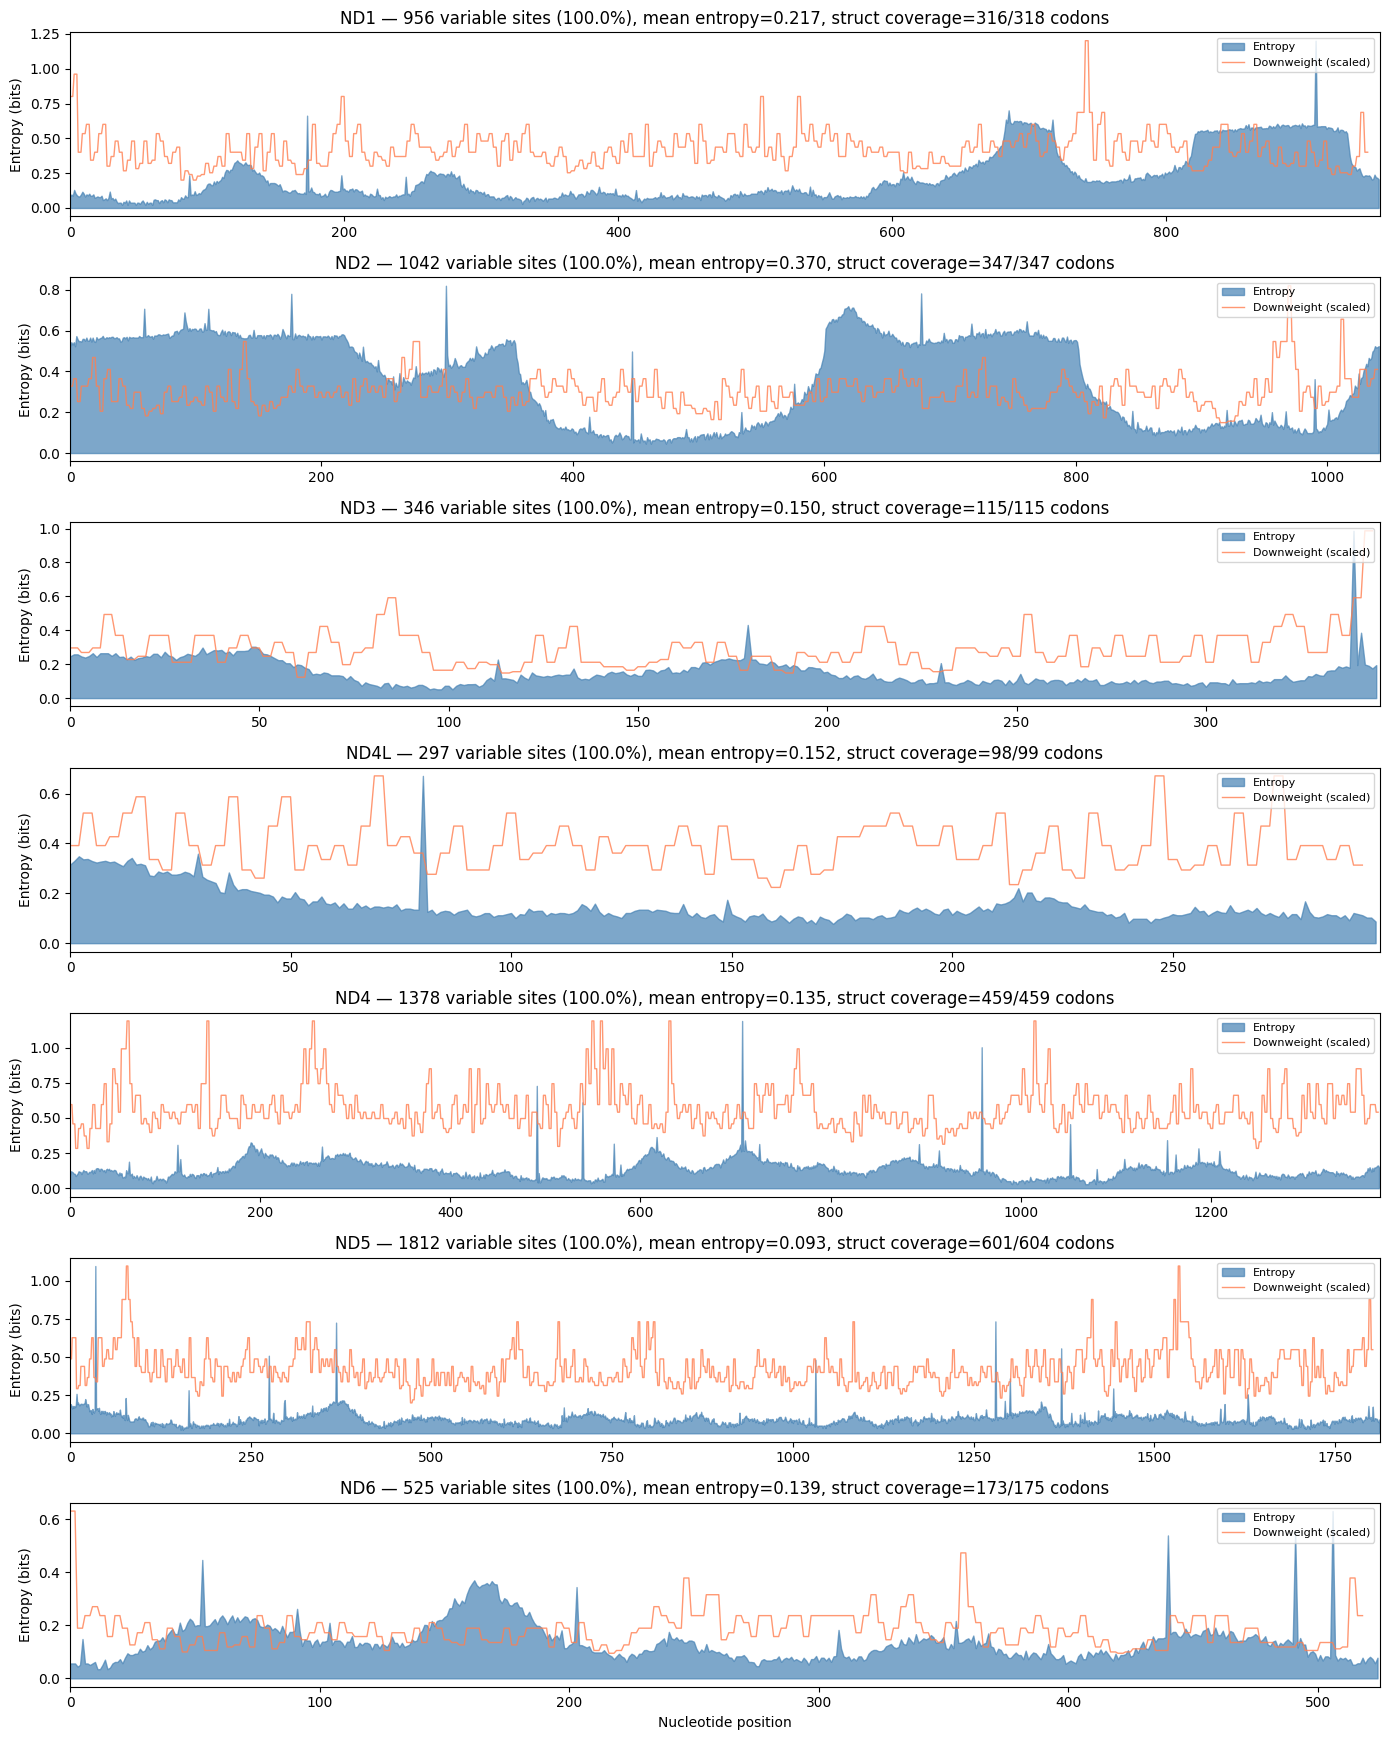

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(nd_genes), 1, figsize=(14, 2.5 * len(nd_genes)))

for ax, gene in zip(axes, sorted(nd_genes.keys(), key=lambda x: nd_genes[x]["start"])):
    stats = gene_variability[gene]
    entropy = stats["per_position_entropy"]
    length = stats["length"]
    n_codons = length // 3
    
    # Expand downweights to nucleotide level for comparison
    dw = mito_contact_summary[gene]["downweight"]
    struct_len = len(dw)
    
    # Create nucleotide-level downweight (repeat each residue weight 3x)
    dw_expanded = np.repeat(dw, 3)[:n_codons * 3]
    
    # Plot entropy
    positions = np.arange(length)
    ax.fill_between(positions, entropy, alpha=0.7, label="Entropy", color="steelblue")
    
    # Overlay downweight (scaled to entropy range for visibility)
    if len(dw_expanded) > 0:
        dw_positions = np.arange(len(dw_expanded))
        dw_scaled = dw_expanded * (entropy.max() / dw_expanded.max()) if dw_expanded.max() > 0 else dw_expanded
        ax.plot(dw_positions, dw_scaled, color="coral", alpha=0.8, lw=1, label="Downweight (scaled)")
    
    ax.set_xlim(0, length)
    ax.set_ylabel("Entropy (bits)")
    ax.set_title(f"{gene} — {stats['n_variable_sites']} variable sites ({stats['pct_variable']:.1f}%), "
                 f"mean entropy={stats['mean_entropy']:.3f}, struct coverage={struct_len}/{n_codons} codons")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Nucleotide position")
plt.tight_layout()
plt.show()

In [11]:
# Verify character composition in extracted ND genes (using processed data from above)
from collections import Counter

total_counts = Counter()
per_gene_counts = {}

for gene, gene_seqs in amtdb_nd_seqs.items():
    gene_counts = Counter()
    for seq in gene_seqs.values():
        gene_counts.update(seq)
    per_gene_counts[gene] = gene_counts
    total_counts.update(gene_counts)

total_bases = sum(total_counts.values())
print(f"Total genes: {len(amtdb_nd_seqs)}")
print(f"Total samples per gene: {len(amtdb_nd_seqs['ND1'])}")
print(f"Total bases (extracted ND genes): {total_bases:,}")

print(f"\n{'='*50}")
print("NUCLEOTIDE COMPOSITION (extracted ND genes)")
print(f"{'='*50}")

# Standard nucleotides
standard = ['A', 'C', 'G', 'T']
for nuc in standard:
    count = total_counts[nuc]
    pct = 100 * count / total_bases
    print(f"{nuc}: {count:>12,} ({pct:>6.2f}%)")

# Non-standard characters
non_standard = {k: v for k, v in total_counts.items() if k not in standard}
if non_standard:
    print(f"\n{'='*50}")
    print("NON-STANDARD CHARACTERS")
    print(f"{'='*50}")
    for char, count in sorted(non_standard.items(), key=lambda x: -x[1]):
        pct = 100 * count / total_bases
        print(f"{repr(char)}: {count:>12,} ({pct:>6.3f}%)")
else:
    print(f"\n{'='*50}")
    print("NO NON-STANDARD CHARACTERS (only A, C, G, T)")
    print(f"{'='*50}")

# Per-gene breakdown
print(f"\n{'='*50}")
print("PER-GENE N CONTENT")
print(f"{'='*50}")
print(f"{'Gene':<6} {'Total bases':>12} {'N count':>10} {'N %':>8}")
print("-" * 40)
for gene in sorted(nd_genes.keys(), key=lambda x: nd_genes[x]["start"]):
    counts = per_gene_counts[gene]
    gene_total = sum(counts.values())
    n_count = counts.get('N', 0)
    n_pct = 100 * n_count / gene_total if gene_total > 0 else 0
    print(f"{gene:<6} {gene_total:>12,} {n_count:>10,} {n_pct:>7.2f}%")

Total genes: 7
Total samples per gene: 1374
Total bases (extracted ND genes): 8,733,144

NUCLEOTIDE COMPOSITION (extracted ND genes)
A:    2,473,965 ( 28.33%)
C:    2,696,037 ( 30.87%)
G:    1,072,809 ( 12.28%)
T:    2,246,098 ( 25.72%)

NON-STANDARD CHARACTERS
'N':      244,235 ( 2.797%)

PER-GENE N CONTENT
Gene    Total bases    N count      N %
----------------------------------------
ND1       1,313,544     49,687    3.78%
ND2       1,431,708    109,352    7.64%
ND3         475,404      9,247    1.95%
ND4L        408,078      8,024    1.97%
ND4       1,893,372     31,346    1.66%
ND5       2,489,688     23,915    0.96%
ND6         721,350     12,664    1.76%
